In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels joblib


Shape: (4600, 18)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-nul

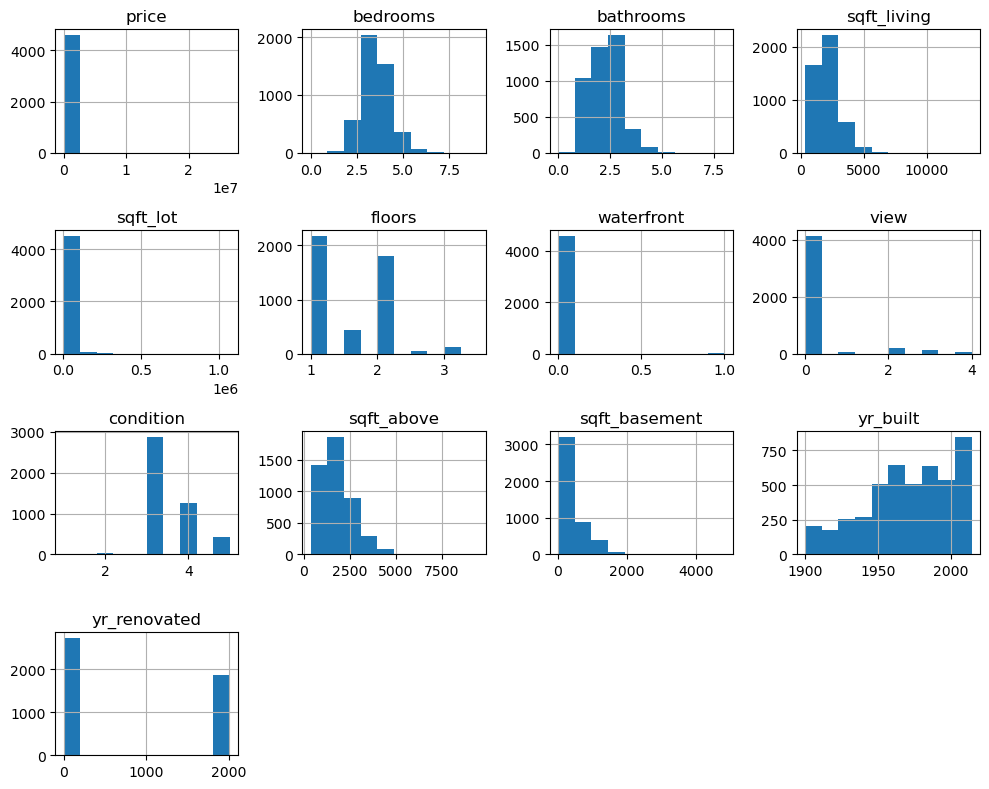

ValueError: could not convert string to float: '2014-05-02 00:00:00'

<Figure size 600x500 with 0 Axes>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_data.csv")

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescriptive stats:")
print(df.describe().round(2))

print("\nMissing values per column:")
print(df.isnull().sum())

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation matrix")
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.drop_duplicates()

features = ['bedrooms', 'sqft_living']   # adjust to your dataset
target = 'price'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

print("Training size:", X_train.shape)


Training size: (3680, 2)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.4f}")

# Coefficients
coeff_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
})
print("\nCoefficients:")
print(coeff_df)
print("\nIntercept:", model.intercept_)


MSE: 0.08
RMSE: 0.28
MAE: 0.25
R^2: -0.0067

Coefficients:
        feature  coefficient
0    sq_footage    -0.011108
1      bedrooms    -0.013073
2     bathrooms     0.012592
3           age    -0.022318
4  neighborhood    -0.008514

Intercept: 0.5184680434389758


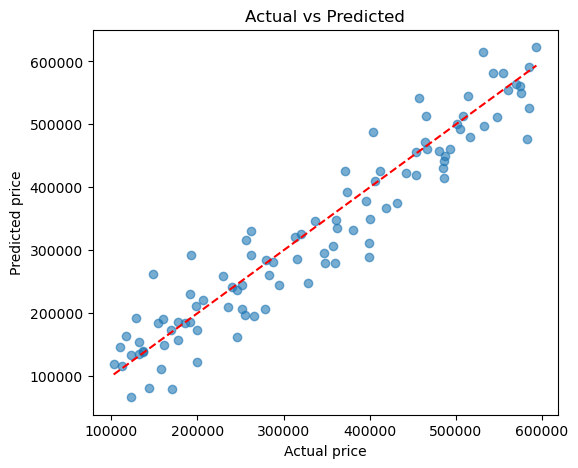

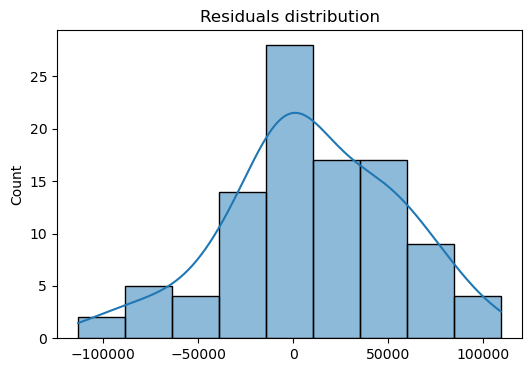

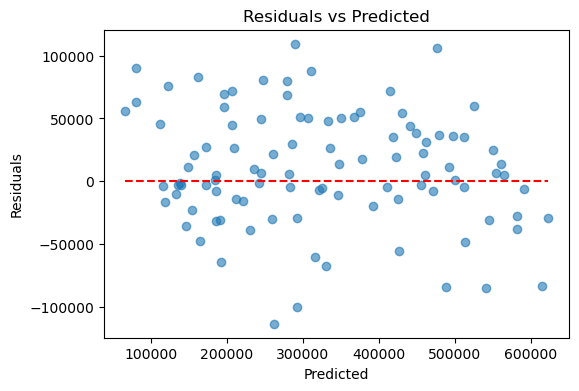

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.hlines(0, xmin=y_pred.min(), xmax=y_pred.max(), colors='r', linestyles='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()
